# SNAM: Sparse Neural Additive Model

SNAM reuses NAM shape networks and adds group-lasso regularization so entire feature or interaction subnetworks can be suppressed.


## Model in one view


$$
\eta(x)=\beta_0+\sum_j f_j(x_j)+\sum_{S\in\mathcal I}f_S(x_S),
\qquad
\Omega(\theta)=\lambda\sum_g\lVert\theta_g\rVert_2.
$$

Each group $g$ is one complete term network, making sparsity term-wise rather than weight-wise.



SNAM applies a group penalty to all parameters belonging to one additive term.
Unlike element-wise $\ell_1$ regularization, group lasso removes or retains an
entire feature function, so sparsity aligns with the model's semantic units.
The nonsmooth penalty competes with predictive loss: larger values produce
fewer active terms but can shrink useful shapes.

The selection result is conditional on preprocessing, network capacity, and
optimization. It should therefore be treated as structured regularization,
not as a classical hypothesis test. Stability across seeds or resamples is a
more informative diagnostic than a single active-term set.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2563EB", "#F97316", "#10B981", "#8B5CF6", "#EF4444"]

rng = np.random.default_rng(7)
n = 180
X = pd.DataFrame({
    "x1": rng.uniform(-1.0, 1.0, n),
    "x2": rng.normal(size=n),
    "group": rng.choice(["a", "b", "c"], size=n),
})
y = (
    np.sin(np.pi * X["x1"])
    + 0.35 * X["x2"] ** 2
    + 0.30 * (X["group"] == "b")
    + rng.normal(0.0, 0.12, n)
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7
)


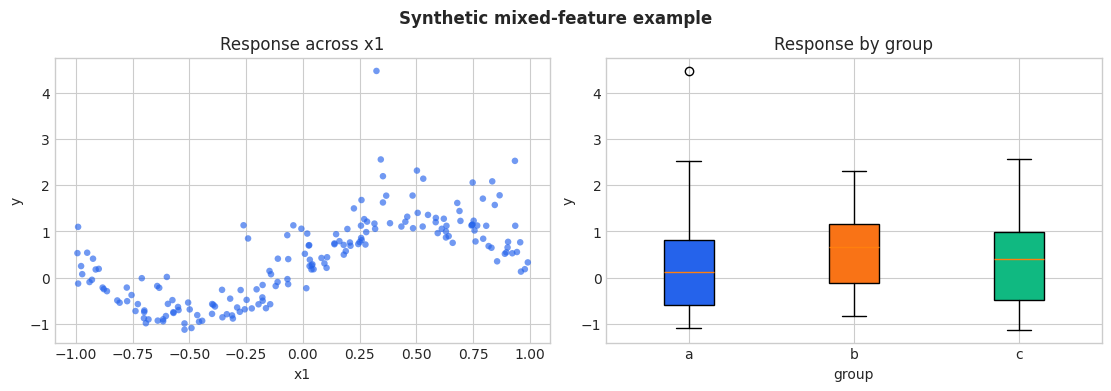

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
axes[0].scatter(X["x1"], y, s=22, alpha=0.65, color=COLORS[0], edgecolor="none")
axes[0].set(title="Response across x1", xlabel="x1", ylabel="y")

group_order = ["a", "b", "c"]
group_values = [y[X["group"].to_numpy() == level] for level in group_order]
boxes = axes[1].boxplot(group_values, tick_labels=group_order, patch_artist=True)
for patch, color in zip(boxes["boxes"], COLORS, strict=False):
    patch.set_facecolor(color)
axes[1].set(title="Response by group", xlabel="group", ylabel="y")
fig.suptitle("Synthetic mixed-feature example", fontweight="bold")
plt.show()
plt.close(fig)


## Fit the model


In [3]:
from nampy.models import SNAMClassifier, SNAMLSS, SNAMRegressor


model = SNAMRegressor(
    layer_sizes=[32, 16],
    group_lasso_lambda=2e-4,
    group_lasso_include_interactions=True,
    interactions=(("x1", "x2"),),
    dropout=0.0,
)
model.get_params(deep=False)


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'activation': torch.nn.modules.activation.ReLU,
 'adaptive_width': False,
 'batch_norm': False,
 'dropout': 0.0,
 'feature_dropout': 0.0,
 'feature_layer': 'linear',
 'feature_output_bias': True,
 'feature_widths': {},
 'group_lasso_include_interactions': True,
 'group_lasso_lambda': 0.0002,
 'interaction_degree': None,
 'interactions': (('x1', 'x2'),),
 'intercept': True,
 'l2_regularization': 0.0,
 'layer_norm': False,
 'layer_sizes': [32, 16],
 'lr': 0.0001,
 'lr_factor': 0.1,
 'lr_patience': 10,
 'norm': None,
 'num_basis_functions': 1000,
 'output_regularization': 0.0,
 'regularize_interactions': False,
 'skip_connections': False,
 'units_multiplier': 2,
 'use_glu': False,
 'weight_decay': 1e-06,
 'feature_preprocessing': None,
 'n_bins': 64,
 'numerical_preprocessing': 'ple',
 'categorical_preprocessing': 'int',
 'use_decision_tree_bins': False,
 'binning_strategy': 'uniform',
 'task': 'regression',
 'cat_cutoff': 0.03,
 'treat_all_integers_as_numerical': False,
 'degree': 3,
 '

In [4]:
model.fit(
    X_train,
    y_train,
    max_epochs=3,
    batch_size=64,
    random_state=7,
    logger=False,
    enable_progress_bar=False,
    enable_model_summary=False,
)
predictions = model.predict(X_test)
r2 = model.score(X_test, y_test)
metrics = model.evaluate(X_test, y_test)
components = model.predict_components(X_test)
explanation = model.explain_terms(X_test, max_bins=24, center=True)
importance = model.term_importance(X_test, center=True)
interaction_importance = model.interaction_importance(X_test, center=True)
display({"R2": r2, **metrics})
display(importance)
display(explanation.head(12))


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger

`Trainer.fit` stopped: `max_epochs=3` reached.


{'R2': 0.12250531108994289, 'Mean Squared Error': 0.6124107071994938}

,term,term_type,output,importance
0,x1:x2,interaction,0,0.074818
1,group,main,0,0.037361
2,x1,main,0,0.023879
3,x2,main,0,0.021125


,term,term_type,output,value,value_2,contribution,count,importance
0,x1,main,0,-0.965,NaN,0.015477,2,0.023879
1,x1,main,0,-0.8895,NaN,0.007676,2,0.023879
2,x1,main,0,-0.7905,NaN,-0.027483,2,0.023879
3,x1,main,0,-0.6915,NaN,-0.031123,2,0.023879
4,x1,main,0,-0.58,NaN,-0.019581,2,0.023879
5,x1,main,0,-0.4875,NaN,-0.010599,2,0.023879
6,x1,main,0,-0.35,NaN,-0.005805,1,0.023879
7,x1,main,0,-0.209,NaN,-0.013615,2,0.023879
8,x1,main,0,-0.12505,NaN,-0.025011,2,0.023879
9,x1,main,0,-0.05205,NaN,-0.034791,2,0.023879


## Evaluate and explain


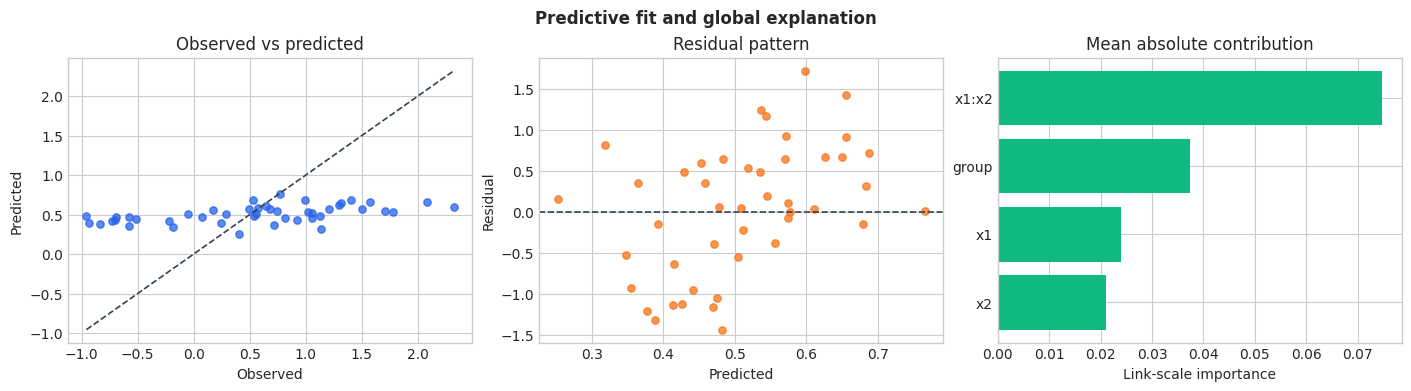

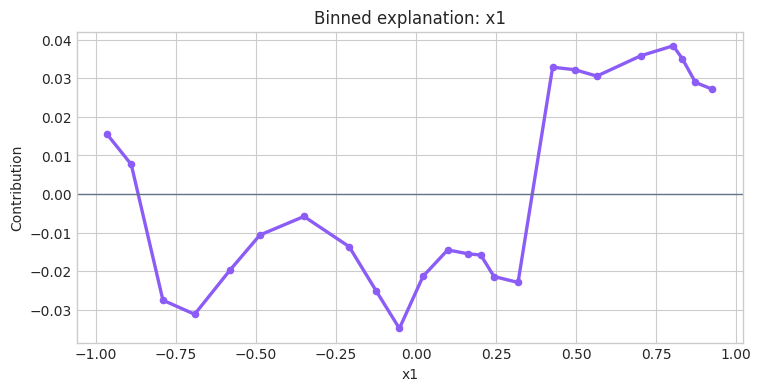

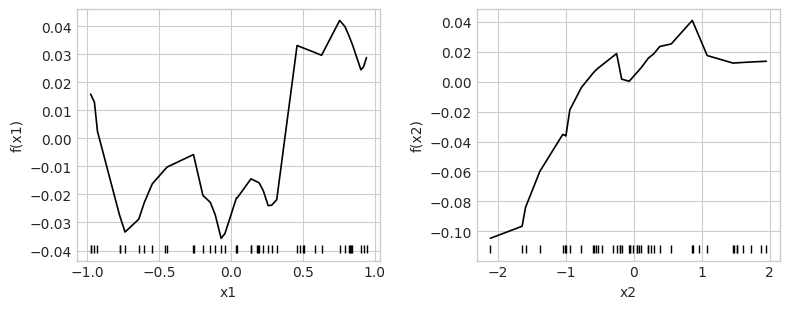

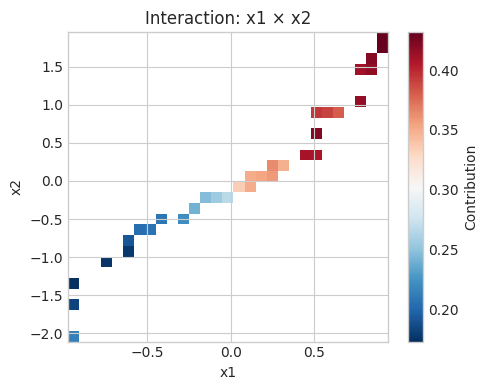

In [5]:
observed = np.asarray(y_test).reshape(-1)
fitted = np.asarray(predictions).reshape(-1)
residual = observed - fitted

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
axes[0].scatter(observed, fitted, s=28, alpha=0.75, color=COLORS[0])
lo = min(observed.min(), fitted.min())
hi = max(observed.max(), fitted.max())
axes[0].plot([lo, hi], [lo, hi], "--", color="#334155", linewidth=1.2)
axes[0].set(title="Observed vs predicted", xlabel="Observed", ylabel="Predicted")

axes[1].scatter(fitted, residual, s=28, alpha=0.75, color=COLORS[1])
axes[1].axhline(0.0, color="#334155", linestyle="--", linewidth=1.2)
axes[1].set(title="Residual pattern", xlabel="Predicted", ylabel="Residual")

importance_plot = (
    importance.groupby("term", as_index=False)["importance"]
    .mean()
    .sort_values("importance")
)
axes[2].barh(importance_plot["term"], importance_plot["importance"], color=COLORS[2])
axes[2].set(title="Mean absolute contribution", xlabel="Link-scale importance")
fig.suptitle("Predictive fit and global explanation", fontweight="bold")
plt.show()
plt.close(fig)

main_effects = explanation.loc[
    (explanation["term_type"] == "main") & (explanation["output"] == 0)
].copy()
main_effects["numeric_value"] = pd.to_numeric(main_effects["value"], errors="coerce")
main_effects = main_effects.dropna(subset=["numeric_value"])
if not main_effects.empty:
    numeric_terms = set(main_effects["term"])
    top_term = next(
        term
        for term in importance_plot.sort_values("importance", ascending=False)["term"]
        if term in numeric_terms
    )
    curve = main_effects.loc[main_effects["term"] == top_term].sort_values("numeric_value")
    if not curve.empty:
        fig, ax = plt.subplots(figsize=(7.5, 3.8), constrained_layout=True)
        ax.plot(curve["numeric_value"], curve["contribution"], color=COLORS[3], linewidth=2.4)
        ax.scatter(curve["numeric_value"], curve["contribution"], s=20, color=COLORS[3])
        ax.axhline(0.0, color="#64748B", linewidth=1)
        ax.set(title=f"Binned explanation: {top_term}", xlabel=top_term, ylabel="Contribution")
        plt.show()
        plt.close(fig)

term_figures = model.plot_terms(X_test, center=True, rug=True, pages=1)
interaction_terms = interaction_importance["term"].astype(str).tolist()
interactions_are_raw_columns = all(
    all(
        part in X_test.columns
        and pd.api.types.is_numeric_dtype(X_test[part])
        for part in term.split(":")
    )
    for term in interaction_terms
)
if interaction_terms and interactions_are_raw_columns:
    model.plot_interactions(X_test)


## Model-specific controls

`group_lasso_lambda` controls term selection. Compare term importance across penalty strengths and use `model_complexity` for fitted parameter counts.


In [6]:
display(model.term_importance(X_test))
display(model.model_complexity())


,term,term_type,output,importance
0,x1:x2,interaction,0,0.311395
1,x1,main,0,0.288888
2,x2,main,0,0.117835
3,group,main,0,0.046842


{'total_parameters': 4901, 'trainable_parameters': 4901}

## Supported task variants

SNAM has `SNAMRegressor`, `SNAMClassifier`, and `SNAMLSS`; all share the same group penalty.


In [7]:
task_variants = {"regression": SNAMRegressor(), "classification": SNAMClassifier(), "distributional": SNAMLSS()}


## References

- [Xu et al. (2022), Sparse Neural Additive Models](https://arxiv.org/abs/2202.12482).
